In [1]:
import pandas as pd
import matplotlib.pyplot as plt

deals_df = pd.read_csv("clear_deals.csv")
projects_df = pd.read_csv("clear_projects.csv")

In [12]:
projects_buildings_df = (
    projects_df
    .groupby("id_корпуса")
    .agg(
        # стадия строительства корпус
        стадия_строительства=("стадия_строительства", "first"),

        # этажность дома
        building_floors_count=("этаж", "nunique"),

        # общее количество квартир в корпусе
        total_flats_in_building=("количество_лотов", "sum"),
    )
    .reset_index()
)

projects_buildings_df.head()


,id_корпуса,стадия_строительства,building_floors_count,total_flats_in_building
0,002b4f20e97d6ca8ac349b5e2e9e81d3,Монтажные и отделочные работы,16,333
1,0076fc28a53eb506b7fc91475d31dea3,Монтажные и отделочные работы,10,235
2,0081bc4d4059f46b3b42276ba8aee782,Введен в эксплуатацию,18,732
3,009d5290e93e353bb27e3f01b505f5b7,Монтажные и отделочные работы,16,703
4,013e43142be6303646e81ccd28432986,Введен в эксплуатацию,18,190


In [ ]:
deals_count_by_building_df = (
    deals_df
    .groupby("id_корпуса")
    .size()
    .reset_index(name="deals_count")
)

deals_count_by_building_df.head()


,id_корпуса,deals_count
0,002b4f20e97d6ca8ac349b5e2e9e81d3,267
1,0076fc28a53eb506b7fc91475d31dea3,98
2,0081bc4d4059f46b3b42276ba8aee782,312
3,009d5290e93e353bb27e3f01b505f5b7,28
4,013e43142be6303646e81ccd28432986,154


In [13]:
projects_buildings_df = projects_buildings_df.merge(
    deals_count_by_building_df,
    on="id_корпуса",
    how="left"
)

# если по корпусу не было сделок
projects_buildings_df["deals_count"] = (
    projects_buildings_df["deals_count"]
    .fillna(0)
    .astype(int)
)


In [14]:
projects_buildings_df

,id_корпуса,стадия_строительства,building_floors_count,total_flats_in_building,deals_count
0,002b4f20e97d6ca8ac349b5e2e9e81d3,Монтажные и отделочные работы,16,333,267
1,0076fc28a53eb506b7fc91475d31dea3,Монтажные и отделочные работы,10,235,98
2,0081bc4d4059f46b3b42276ba8aee782,Введен в эксплуатацию,18,732,312
3,009d5290e93e353bb27e3f01b505f5b7,Монтажные и отделочные работы,16,703,28
4,013e43142be6303646e81ccd28432986,Введен в эксплуатацию,18,190,154
...,...,...,...,...,...
414,fd01b8c0e5ea83c9252268d6806cf6e6,Монтажные и отделочные работы,21,465,73
415,fd11279466f6069c8fefd1baa5884d18,Введен в эксплуатацию,15,535,134
416,fde1f8ad4322f757d44bdf4c634df283,Введен в эксплуатацию,19,945,153
417,fe3fbf2588f1c241871893ab71fee571,Монтажные и отделочные работы,10,68,34


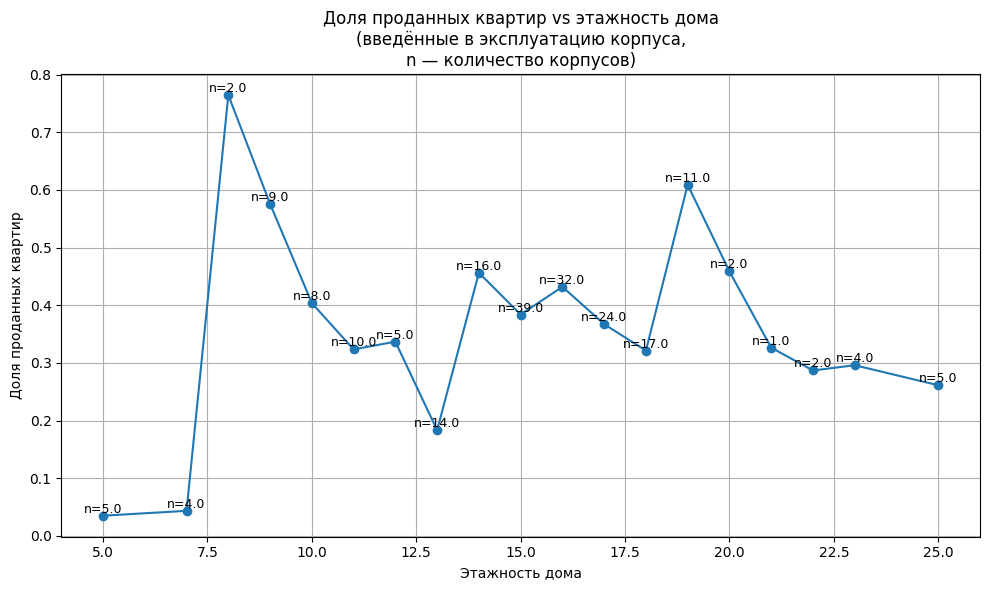

In [19]:
commissioned_buildings_df = projects_buildings_df[
    projects_buildings_df["стадия_строительства"] == "Введен в эксплуатацию"
].copy()

commissioned_buildings_df["sales_share"] = (
    commissioned_buildings_df["deals_count"]
    / commissioned_buildings_df["total_flats_in_building"]
)

height_sales_share_commissioned_df = (
    commissioned_buildings_df
    .groupby("building_floors_count")
    .agg(
        mean_sales_share=("sales_share", "mean"),
        buildings_count=("id_корпуса", "count")
    )
    .reset_index()
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    height_sales_share_commissioned_df["building_floors_count"],
    height_sales_share_commissioned_df["mean_sales_share"],
    marker="o"
)

# подписи n над точками
for _, row in height_sales_share_commissioned_df.iterrows():
    plt.text(
        row["building_floors_count"],
        row["mean_sales_share"],
        f'n={row["buildings_count"]}',
        fontsize=9,
        ha='center',
        va='bottom'
    )

plt.xlabel("Этажность дома")
plt.ylabel("Доля проданных квартир")
plt.title(
    "Доля проданных квартир vs этажность дома\n"
    "(введённые в эксплуатацию корпуса,\n"
    "n — количество корпусов)"
)

plt.grid(True)
plt.tight_layout()
plt.show()



Коэффициент наклона (β1): 0.0056
Свободный член (β0): 0.2937
R² (взвешенный): 0.029


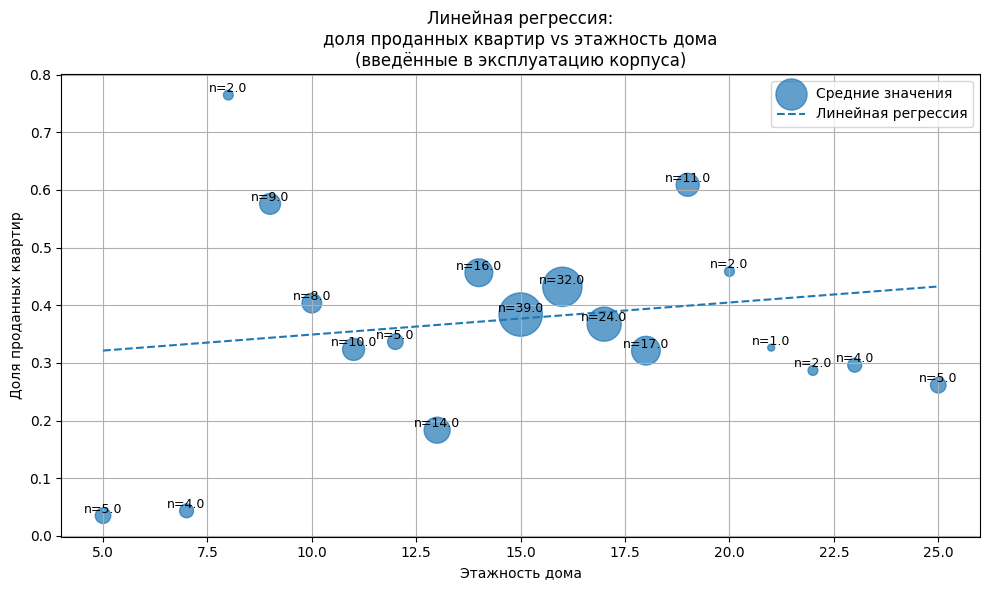

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# X, y, веса
X = height_sales_share_commissioned_df["building_floors_count"].values.reshape(-1, 1)
y = height_sales_share_commissioned_df["mean_sales_share"].values
weights = height_sales_share_commissioned_df["buildings_count"].values

# модель
lin_reg = LinearRegression()
lin_reg.fit(X, y, sample_weight=weights)

# предсказания
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = lin_reg.predict(x_line)

# коэффициенты
slope = lin_reg.coef_[0]
intercept = lin_reg.intercept_
r2 = lin_reg.score(X, y, sample_weight=weights)

print(f"Коэффициент наклона (β1): {slope:.4f}")
print(f"Свободный член (β0): {intercept:.4f}")
print(f"R² (взвешенный): {r2:.3f}")

plt.figure(figsize=(10, 6))

# точки
plt.scatter(
    height_sales_share_commissioned_df["building_floors_count"],
    height_sales_share_commissioned_df["mean_sales_share"],
    s=height_sales_share_commissioned_df["buildings_count"] * 25,
    alpha=0.7,
    label="Средние значения"
)

# линия регрессии
plt.plot(
    x_line,
    y_line,
    linestyle="--",
    label="Линейная регрессия"
)

# подписи n
for _, row in height_sales_share_commissioned_df.iterrows():
    plt.text(
        row["building_floors_count"],
        row["mean_sales_share"],
        f'n={row["buildings_count"]}',
        fontsize=9,
        ha='center',
        va='bottom'
    )

plt.xlabel("Этажность дома")
plt.ylabel("Доля проданных квартир")
plt.title(
    "Линейная регрессия:\n"
    "доля проданных квартир vs этажность дома\n"
    "(введённые в эксплуатацию корпуса)"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

